# Exercise 1: Chemostat with Cell Recycle


In [12]:
import numpy as np
import matplotlib.pyplot as plt


# Params
Yxs   = 0.5    # g-cells / g-substrate
S0    = 2.0    # g/L  (feed substrate)
F     = 1500   # mL/h
V     = 1000   # mL
mu_m  = 1.0    # h^-1
Ks    = 0.01   # g/L
alpha = 0.5    # recycle ratio
C     = 2.0    # concentration factor

D = F / V      # dilution rate [h^-1]


## Part (a): Mass balance on cell concentration — showing μ < D at steady state

**Cell mass balance around the fermenter** (in – out + generation = accumulation = 0 at SS):

$$\underbrace{F \cdot X_0}_{\text{feed}} + \underbrace{\alpha F \cdot C X_1}_{\text{recycle in}} - \underbrace{(1+\alpha)F \cdot X_1}_{\text{out}} + \underbrace{\mu X_1 V}_{\text{growth}} = 0$$

Since $X_0 = 0$:
$$\alpha F C X_1 - (1+\alpha)F X_1 + \mu X_1 V = 0$$

Dividing by $X_1 V$ (assuming $X_1 \neq 0$):
$$\mu = D\left[(1+\alpha) - \alpha C\right] = D\left[1 + \alpha(1-C)\right]$$

where $D = F/V$.

Since $C > 1$ (concentrator), the term $\alpha(1-C) < 0$, so:
$$\boxed{\mu = D[1 + \alpha(1-C)] < D}$$

The chemostat **can therefore operate at dilution rates $D$ higher than the specific growth rate $\mu$**, because the cell recycle retains biomass in the reactor, partially decoupling residence time from cell washout.

## Part (b)

In [13]:
# From part (a):
mu = D * (1 + alpha * (1 - C))

print(f"\n  μ = {mu:.4f} h⁻¹")
print(f"  D = {D:.4f} h⁻¹  →  μ < D confirmed: {mu < D}")


  μ = 0.7500 h⁻¹
  D = 1.5000 h⁻¹  →  μ < D confirmed: True


## Part (c)

The Monod equation 
$$\mu = \frac{\mu_m \cdot S}{K_s + S} $$
Rearraning, becomes:
$$S = \frac{\mu \cdot K_s}{\mu_m - \mu} $$

In [14]:
# Rearranged Monod equation
S = mu * Ks / (mu_m - mu)

print(f"\n  S = {S:.5f} g/L")
print(f"  (This is the steady-state substrate concentration inside the reactor)")


  S = 0.03000 g/L
  (This is the steady-state substrate concentration inside the reactor)


## Part (d)

Substrate balance around fermenter:
$$F \cdot S_0 + \alpha F \cdot S - (1 + \alpha)F\cdot S - \frac{\mu}{Y_{xs}} \cdot X_1 \cdot V = 0$$
$$=> F\cdot (S_0 - S) = \frac{\mu}{Y_{xs}} \cdot X_1 \cdot V$$
$$=> X_1 = Y_{xs} \cdot D \cdot \frac{(S_0 - S)}{\mu}$$

In [15]:
X1 = Yxs * D * (S0 - S) / mu
print(f"X₁ = {X1:.4f} g/L")
print(f"(Cell concentration inside the fermenter / recycle stream)")

X₁ = 1.9700 g/L
(Cell concentration inside the fermenter / recycle stream)


## Part (e)

Cell balance around cell separator (no reaction)
$$(1 + \alpha)F \cdot X_1 = \alpha F \cdot (C \cdot X_1) + F \cdot X_2$$
$$=> X_2 = X_1 \cdot [1 + \alpha(1 - C)]$$

In [16]:
X2 = X1 * (1 + alpha * (1 - C))
print(f"X₂ = {X2:.4f} g/L")

X₂ = 0.9850 g/L



## Part (f):

### Range for α

From part (a): $\mu = D[1 + \alpha(1-C)]$

For cells to grow, we need $\mu > 0$ and $\mu \leq \mu_m$. At washout, $\mu \to \mu_m$:

$$D_{max} = \frac{\mu_m}{1 + \alpha(1-C)}$$

For $D_{max} > 0$ and physically meaningful (no negative growth), we need:
$$1 + \alpha(1-C) > 0 \implies \alpha < \frac{1}{C-1}$$

Also $\alpha \geq 0$, so: $\boxed{0 \leq \alpha < \dfrac{1}{C-1}}$

For $C=2$: $0 \leq \alpha < 1$.

### α = 0 means no recycle — the system reduces to a standard chemostat.
In that case $D_{max} = \mu_m$ (classic washout condition).

In [17]:
# D_max as a function of α  (for fixed C=2)
alpha_max = 1/(C - 1)   # upper bound on α
print(f"For C = {C}: valid range 0 ≤ α < {alpha_max:.3f}")
print(f"D_max formula: D_max = μ_m / [1 + α(1-C)]")
print()

alpha_vals = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9])  # different α values
alpha_range = np.linspace(0, alpha_max * 0.99, 200)

Dmax_vals = mu_m / (1 + alpha_range * (1 - C))

print("D_max for selected α values:")
for a in alpha_vals:
    dmax = mu_m / (1 + a*(1-C))
    print(f"  α = {a:.1f}  →  D_max = {dmax:.4f} h⁻¹")

For C = 2.0: valid range 0 ≤ α < 1.000
D_max formula: D_max = μ_m / [1 + α(1-C)]

D_max for selected α values:
  α = 0.0  →  D_max = 1.0000 h⁻¹
  α = 0.2  →  D_max = 1.2500 h⁻¹
  α = 0.4  →  D_max = 1.6667 h⁻¹
  α = 0.6  →  D_max = 2.5000 h⁻¹
  α = 0.8  →  D_max = 5.0000 h⁻¹
  α = 0.9  →  D_max = 10.0000 h⁻¹


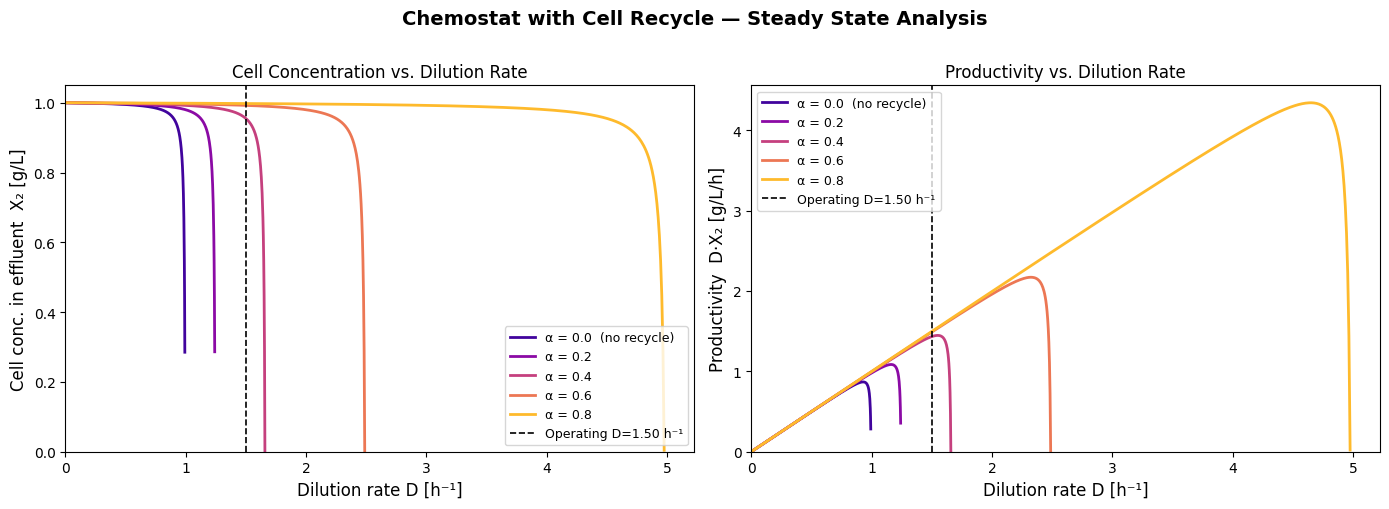

In [18]:
def steady_state(D_val, alpha_val, C_val=C, mu_m_=mu_m, Ks_=Ks, S0_=S0, Yxs_=Yxs):
    """Compute steady-state X1, X2, S, productivity for given D and α."""
    factor = 1 + alpha_val * (1 - C_val)
    mu_val = D_val * factor
    if mu_val <= 0 or mu_val >= mu_m_:
        return np.nan, np.nan, np.nan, np.nan
    S_val  = mu_val * Ks_ / (mu_m_ - mu_val)
    if S_val >= S0_:
        return np.nan, np.nan, np.nan, np.nan
    X1_val = Yxs_ * D_val * (S0_ - S_val) / mu_val
    X2_val = X1_val * factor
    Prod   = D_val * X2_val    # productivity = D * X2 [g/L/h]
    return X1_val, X2_val, S_val, Prod

# ── Plotting ──────────────────────────────────────────────────────────────────
alpha_plot = [0.0, 0.2, 0.4, 0.6, 0.8]
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(alpha_plot)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chemostat with Cell Recycle — Steady State Analysis",
             fontsize=14, fontweight='bold', y=1.01)

ax1, ax2 = axes

for a, col in zip(alpha_plot, colors):
    Dmax_a = mu_m / (1 + a * (1 - C))
    D_range = np.linspace(0.01, Dmax_a * 0.999, 500)

    X2_arr = []
    P_arr  = []
    D_ok   = []

    for d in D_range:
        x1, x2, s, prod = steady_state(d, a)
        if not np.isnan(x2):
            X2_arr.append(x2)
            P_arr.append(prod)
            D_ok.append(d)

    label = f"α = {a}" + ("  (no recycle)" if a == 0 else "")
    ax1.plot(D_ok, X2_arr, color=col, lw=2, label=label)
    ax2.plot(D_ok, P_arr,  color=col, lw=2, label=label)

# Mark the operating point from parts (b-e)
ax1.axvline(D, color='black', ls='--', lw=1.2, label=f"Operating D={D:.2f} h⁻¹")
ax2.axvline(D, color='black', ls='--', lw=1.2, label=f"Operating D={D:.2f} h⁻¹")

ax1.set_xlabel("Dilution rate D [h⁻¹]", fontsize=12)
ax1.set_ylabel("Cell conc. in effluent  X₂ [g/L]", fontsize=12)
ax1.set_title("Cell Concentration vs. Dilution Rate", fontsize=12)
ax1.legend(fontsize=9)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2.set_xlabel("Dilution rate D [h⁻¹]", fontsize=12)
ax2.set_ylabel("Productivity  D·X₂ [g/L/h]", fontsize=12)
ax2.set_title("Productivity vs. Dilution Rate", fontsize=12)
ax2.legend(fontsize=9)
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

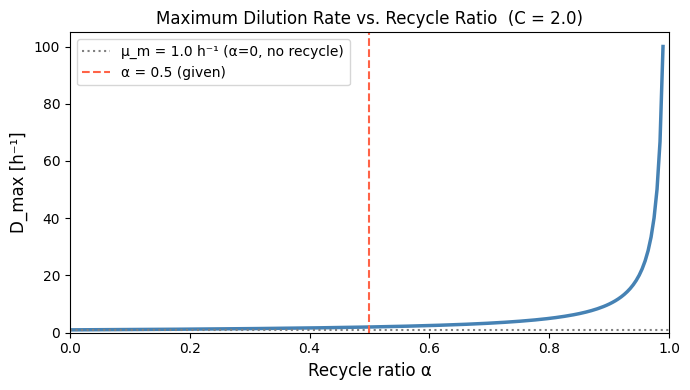

In [19]:
# ── D_max vs α plot ───────────────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_range, Dmax_vals, color='steelblue', lw=2.5)
ax.axhline(mu_m, color='gray', ls=':', lw=1.5, label=f'μ_m = {mu_m} h⁻¹ (α=0, no recycle)')
ax.axvline(alpha, color='tomato', ls='--', lw=1.5, label=f'α = {alpha} (given)')
ax.set_xlabel("Recycle ratio α", fontsize=12)
ax.set_ylabel("D_max [h⁻¹]", fontsize=12)
ax.set_title(f"Maximum Dilution Rate vs. Recycle Ratio  (C = {C})", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, alpha_max)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Summary and Interpretation

### Numerical Results

| Quantity | Value | Unit |
|----------|-------|------|
| Dilution rate $D$ | 1.500 | h⁻¹ |
| Specific growth rate $\mu$ | 0.750 | h⁻¹ |
| Substrate conc. $S$ | 0.0300 | g/L |
| Cell conc. (fermenter) $X_1$ | 1.9700 | g/L |
| Cell conc. (effluent) $X_2$ | 0.9850 | g/L |

### Interpretation

- **μ < D** is confirmed: cell recycle allows operation above the classical washout dilution rate, since biomass is continuously returned to the reactor, reducing the effective cell loss rate.
- **Higher α → higher D_max**: increasing the recycle ratio (more cells returned) extends the operable range. At $\alpha \to 1/(C-1)$, $D_{max} \to \infty$ theoretically (complete recycle).
- **α = 0** (no recycle): the system behaves as a standard chemostat, with $D_{max} = \mu_m = 1$ h⁻¹. Cell washout occurs at exactly $D = \mu_m$.
- **Productivity $D \cdot X_2$** passes through an optimum: at low $D$, few cells are washed out (low throughput); near $D_{max}$, $X_2$ drops sharply toward zero. The productivity maximum lies between these extremes.
- **Higher α** increases cell retention, yielding higher $X_2$ at the same $D$ and shifting the productivity peak to higher dilution rates — improving overall throughput.